First 5 Rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN

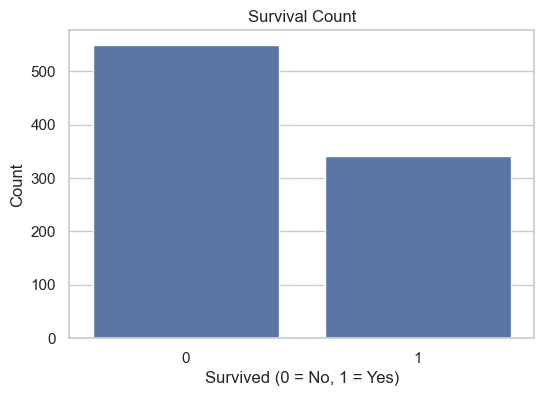

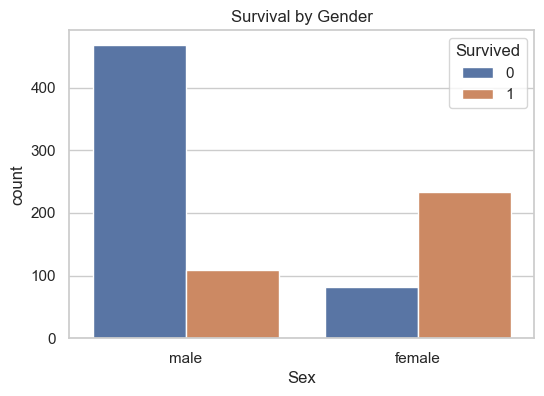

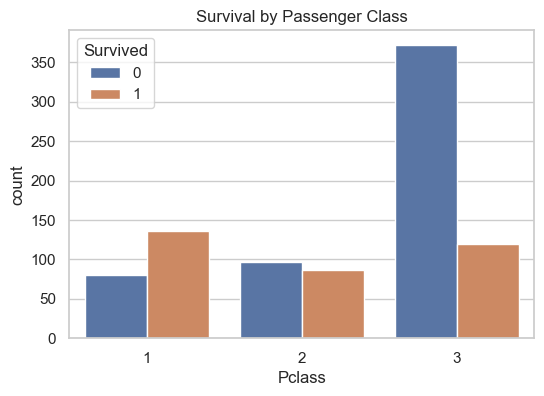

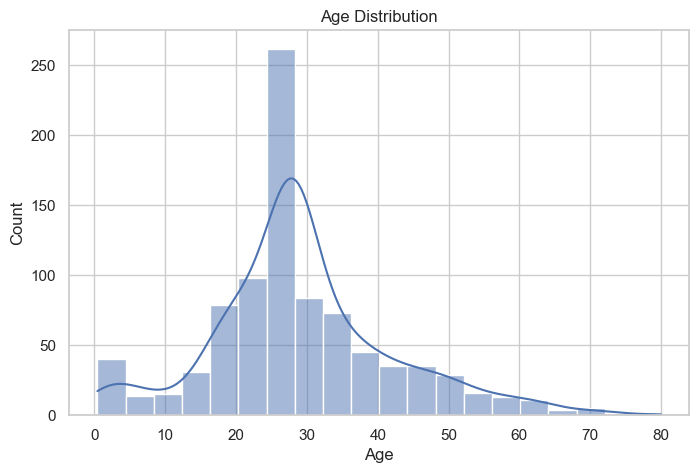

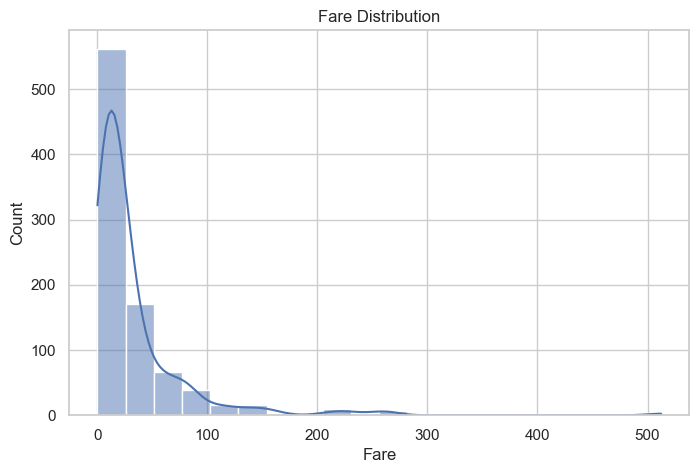

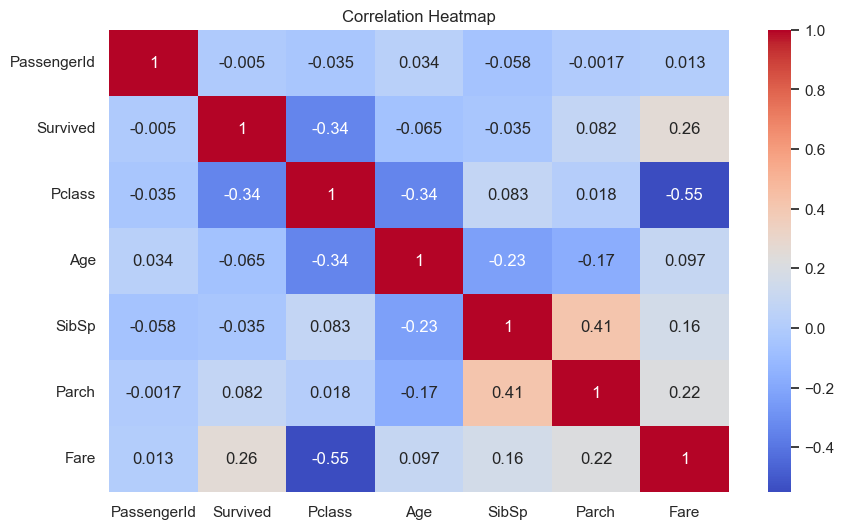

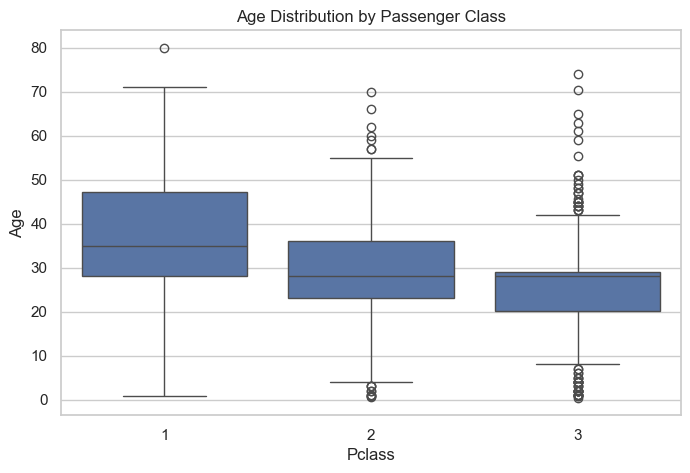

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv(r"Titanic-Dataset.csv")

print("First 5 Rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
print(df.describe())

# Fill missing Age values with median
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing Embarked values with mode
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# Drop Cabin column (many missing values)
if 'Cabin' in df.columns:
    df = df.drop(columns='Cabin')

# Remove duplicate rows
df = df.drop_duplicates()

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())


# EXPLORATORY DATA ANALYSIS (EDA)

# Survival Count
plt.figure(figsize=(6,4))

sns.countplot(x='Survived', data=df)

plt.title("Survival Count")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.show()


# Survival by Gender
plt.figure(figsize=(6,4))

sns.countplot(x='Sex',
              hue='Survived',
              data=df)

plt.title("Survival by Gender")
plt.show()


#  Survival by Passenger Class
plt.figure(figsize=(6,4))

sns.countplot(x='Pclass',
              hue='Survived',
              data=df)

plt.title("Survival by Passenger Class")
plt.show()


# Age Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],
             bins=20,
             kde=True)

plt.title("Age Distribution")
plt.show()


# Fare Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['Fare'],
             bins=20,
             kde=True)

plt.title("Fare Distribution")
plt.show()


# Correlation Heatmap
plt.figure(figsize=(10,6))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()


# Boxplot (Important for EDA)
plt.figure(figsize=(8,5))

sns.boxplot(x='Pclass',
            y='Age',
            data=df)

plt.title("Age Distribution by Passenger Class")
plt.show()